<div style="display: flex; align-items: center;">

  <!-- Logos -->
  <div style="white-space: nowrap;">
    <img 
      src="https://www.upc.edu/comunicacio/ca/identitat/descarrega-arxius-grafics/fitxers-marca-principal/upc-positiu-p3005.png" 
      width="300"
      style="vertical-align: middle;"
    >
    <img 
      src="https://www.hipotecalowcost.com/wp-content/uploads/2019/08/Logo-CaixaBank.png" 
      width="200"
      style="vertical-align: middle;"
    >
  </div>

  <!-- Texto -->
  <div style="margin-left: auto; margin-right: 100px; text-align: right;">
      <p style="margin: 0;"><b>CaixaBank · Advanced Analytics Program</b></p>
      <p style="margin: 0;"><b>Model Risk & Data Science Training</b></p>
      <p style="margin: 0;">Intelligence Data Science and Artificial Intelligence (IDEAI)</p>
  </div>

</div>

# 🖼️ **Redes Neuronales Convolucionales (CNN) para Auditores Bancarios**

## Objetivo del notebook

Este notebook explica las **Redes Neuronales Convolucionales (CNN)** desde una perspectiva aplicada a la **auditoría bancaria**, donde las imágenes más relevantes no suelen ser fotografías naturales, sino **documentos escaneados o capturados**.

La clasificación de imágenes más adecuada para auditoría bancaria es la clasificación de **documentos financieros y evidencias visuales**, por ejemplo:

- Facturas.
- Recibos.
- Cheques.
- Justificantes de transferencia.
- Documentos KYC: DNI, pasaporte, comprobante de domicilio.
- Capturas de banca electrónica.
- Documentos potencialmente alterados o de baja calidad.

En auditoría, una CNN puede ayudar a responder preguntas como:

- ¿Qué tipo de documento ha aportado el cliente o la oficina?
- ¿El documento parece consistente con el tipo declarado?
- ¿La imagen tiene calidad suficiente para revisión?
- ¿Hay señales visuales de manipulación, recorte, sobreimpresión o duplicidad?
- ¿Se puede priorizar qué documentos revisar manualmente?

> Importante: en un entorno bancario real, una CNN **no debe sustituir el juicio auditor**, sino actuar como herramienta de priorización, detección preliminar y control de calidad documental.

## 1. FUNDAMENTOS TEÓRICOS

### 1.1 ¿Qué es una CNN?

Una **CNN** es una red neuronal especializada en procesar datos con estructura espacial, especialmente imágenes. A diferencia de una red neuronal artificial clásica, que recibe una tabla de variables, una CNN recibe una matriz de píxeles.

En auditoría bancaria, una imagen documental puede representarse como una matriz:

- Alto de la imagen.
- Ancho de la imagen.
- Canales de color: escala de grises, RGB, etc.

La CNN aprende patrones visuales como bordes, zonas de texto, sellos, líneas, logotipos, firmas, tablas o estructuras propias de cada documento.

### 1.2 Por qué una CNN es útil en documentos bancarios

Los documentos financieros tienen patrones visuales relativamente estructurados:

| Tipo de documento | Patrones visuales habituales |
|---|---|
| Factura | Cabecera, proveedor, líneas de producto, total, IVA |
| Recibo | Formato estrecho, importes, fecha, comercio |
| Cheque | Línea de firma, número de cheque, campos bancarios |
| Transferencia | IBAN, ordenante, beneficiario, referencia, importe |
| DNI/KYC | Foto, MRZ, campos identificativos, formato oficial |

Una CNN puede aprender estas estructuras visuales sin que el auditor tenga que programar manualmente todas las reglas.

### 1.3 Capas principales de una CNN

Una arquitectura CNN suele contener:

1. **Convoluciones (`Conv2D`)**: detectan patrones locales.
2. **Funciones de activación (`ReLU`)**: introducen no linealidad.
3. **Pooling (`MaxPooling2D`)**: reduce dimensionalidad y conserva patrones relevantes.
4. **Flatten o Global Average Pooling**: convierte mapas de características en vectores.
5. **Capas densas**: realizan la clasificación final.
6. **Softmax o Sigmoid**: devuelven probabilidades de clase.

Para auditoría, estas probabilidades deben interpretarse con cautela. Una probabilidad alta no implica verdad absoluta; implica que el patrón visual se parece mucho a los ejemplos aprendidos.

### 1.4 Convolución explicada de forma intuitiva

Una convolución consiste en pasar un pequeño filtro sobre la imagen. Ese filtro puede aprender a detectar:

- Bordes horizontales.
- Bordes verticales.
- Zonas con texto.
- Marcos.
- Firmas.
- Sellos.
- Patrones repetitivos.

En capas profundas, la CNN combina estos patrones simples para reconocer estructuras más complejas: una factura, un cheque o una captura de transferencia.

### 1.5 Clasificación multiclase vs clasificación binaria

En auditoría bancaria existen dos enfoques muy habituales:

**A) Clasificación multiclase de tipología documental**

Ejemplo: predecir si una imagen es:

- Factura.
- Recibo.
- Cheque.
- Transferencia.
- Documento KYC.

**B) Clasificación binaria de riesgo visual**

Ejemplo: predecir si una imagen es:

- Normal.
- Sospechosa / alterada / ilegible / inconsistente.

En este notebook trabajaremos principalmente con clasificación multiclase de documentos, porque es la base más natural para auditoría documental. También se explica cómo adaptar el modelo a detección de riesgo.

### 1.6 Riesgos específicos en auditoría bancaria

Al usar CNN en auditoría bancaria deben controlarse especialmente:

- **Fuga de información**: nombres de archivo, metadatos o carpetas pueden revelar la clase.
- **Sesgo por origen**: documentos de una oficina o proveedor pueden dominar el entrenamiento.
- **Sobreajuste visual**: el modelo aprende el formato de un proveedor, no el concepto general.
- **Calidad de imagen**: borrosidad, sombras, rotaciones, recortes y baja resolución.
- **Cambios temporales**: nuevos formatos documentales o nuevas plantillas bancarias.
- **Explicabilidad**: el auditor necesita saber qué zona de la imagen activó la predicción.
- **Privacidad**: los documentos pueden contener datos personales o bancarios sensibles.

## 2. CASUÍSTICAS CLAVE PARA AUDITORES DE BANCA

### 2.1 Documentos escaneados frente a fotos móviles

Un mismo documento puede llegar como PDF escaneado, foto de móvil o captura de pantalla. La CNN debe ser robusta a:

- Rotaciones pequeñas.
- Cambios de brillo.
- Sombras.
- Escalado.
- Compresión.
- Ruido.
- Recortes parciales.

Por eso se utiliza **data augmentation**, que genera variaciones artificiales durante el entrenamiento.

### 2.2 Clases desbalanceadas

En bancos puede haber muchas más facturas que cheques, o muchas más transferencias que documentos sospechosos. Si no se controla el desbalanceo, el modelo puede ignorar clases minoritarias.

Soluciones habituales:

- `class_weight`.
- Oversampling de clases minoritarias.
- Métricas por clase.
- Matriz de confusión.
- Umbrales específicos por riesgo.

### 2.3 Métricas relevantes

La precisión global no es suficiente. Para auditoría interesan:

- **Recall por clase crítica**: no perder documentos sospechosos.
- **Precision**: evitar exceso de falsos positivos.
- **F1-score**: equilibrio entre precision y recall.
- **Matriz de confusión**: qué tipos de documento se confunden.
- **Top-k accuracy**: útil si el sistema propone varias clases al auditor.
- **Calibración de probabilidades**: saber si las probabilidades son fiables.

### 2.4 Interpretabilidad visual: Grad-CAM

Para CNN, SHAP puede aplicarse a imágenes, pero suele ser costoso. Una técnica muy habitual es **Grad-CAM**, que genera un mapa de calor mostrando qué zonas de la imagen han influido más en la predicción.

En auditoría, Grad-CAM puede ayudar a responder:

- ¿El modelo se fijó en la firma?
- ¿El modelo se fijó en el total?
- ¿El modelo se fijó en una zona irrelevante como el margen?
- ¿La predicción está basada en un patrón documental razonable?

### 2.5 Uso combinado con OCR y modelos tabulares

Una CNN no tiene por qué trabajar sola. En banca suele combinarse con:

- **OCR** para extraer texto.
- **Reglas de negocio** para validar IBAN, NIF, importes o fechas.
- **Modelos tabulares** para evaluar riesgo del cliente, operación o proveedor.
- **XAI** para explicar variables y zonas visuales.

Ejemplo de pipeline realista:

1. Clasificar tipo de documento con CNN.
2. Extraer texto con OCR.
3. Validar campos críticos con reglas.
4. Calcular score de riesgo con modelo tabular.
5. Enviar a revisión manual si hay inconsistencia.

## 3. PREPARACIÓN DEL ENTORNO

In [1]:
# ============================================================
# 3. PREPARACIÓN DEL ENTORNO
# ============================================================

# Si falta TensorFlow en tu entorno, ejecuta previamente:
# !pip install tensorflow scikit-learn matplotlib pandas numpy

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


## 4. CREACIÓN DE UN DATASET SINTÉTICO DE DOCUMENTOS BANCARIOS

En un caso real, las imágenes procederían de carpetas con documentos anonimizados. Para que el notebook sea reproducible sin depender de ficheros externos, generaremos imágenes sintéticas que imitan estructuras documentales simples.

Clases simuladas:

0. **Factura**: cabecera, líneas de concepto y bloque de total.
1. **Recibo**: formato estrecho con varias líneas y total inferior.
2. **Cheque**: estructura horizontal con línea de firma y campos bancarios.
3. **Transferencia**: bloques de ordenante, beneficiario, IBAN e importe.
4. **KYC / Identidad**: zona de foto y campos identificativos.

Este dataset no sustituye datos reales, pero permite explicar el funcionamiento completo de una CNN aplicada a auditoría bancaria.

In [2]:
# ============================================================
# 4. GENERACIÓN DE IMÁGENES SINTÉTICAS
# ============================================================

IMG_SIZE = 64
N_CLASSES = 5
CLASS_NAMES = ["factura", "recibo", "cheque", "transferencia", "kyc_identidad"]

def add_noise(img, noise_level=0.05):
    noise = np.random.normal(0, noise_level, img.shape)
    return np.clip(img + noise, 0, 1)

def draw_rect(img, x1, y1, x2, y2, value=0.1):
    img[y1:y2, x1:x2] = value

def draw_line(img, x1, y1, x2, y2, value=0.1, thickness=1):
    if y1 == y2:
        img[max(0,y1-thickness):min(IMG_SIZE,y1+thickness+1), x1:x2] = value
    elif x1 == x2:
        img[y1:y2, max(0,x1-thickness):min(IMG_SIZE,x1+thickness+1)] = value

def synthetic_document(label):
    img = np.ones((IMG_SIZE, IMG_SIZE), dtype=np.float32)
    
    # margen documental
    draw_rect(img, 3, 3, 61, 61, 0.95)
    
    if label == 0:  # factura
        draw_rect(img, 8, 7, 36, 12, 0.15)      # cabecera proveedor
        for y in [20, 26, 32, 38]:
            draw_line(img, 8, y, 55, y, 0.25, 1)
        draw_rect(img, 38, 48, 57, 56, 0.2)      # total
    elif label == 1:  # recibo
        draw_rect(img, 20, 5, 44, 11, 0.15)
        for y in range(17, 48, 6):
            draw_line(img, 18, y, 46, y, 0.25, 1)
        draw_rect(img, 22, 52, 43, 58, 0.15)
    elif label == 2:  # cheque
        draw_rect(img, 6, 8, 58, 15, 0.18)
        draw_line(img, 8, 28, 55, 28, 0.25, 1)
        draw_line(img, 8, 40, 35, 40, 0.25, 1)
        draw_line(img, 37, 50, 57, 50, 0.1, 1)  # firma
        draw_rect(img, 45, 18, 56, 25, 0.3)
    elif label == 3:  # transferencia
        draw_rect(img, 7, 7, 57, 14, 0.16)
        draw_rect(img, 9, 20, 30, 28, 0.28)
        draw_rect(img, 34, 20, 55, 28, 0.28)
        draw_line(img, 9, 37, 55, 37, 0.2, 1)  # IBAN
        draw_rect(img, 37, 47, 56, 55, 0.18)   # importe
    elif label == 4:  # KYC / identidad
        draw_rect(img, 8, 10, 26, 34, 0.25)    # foto
        for y in [12, 18, 24, 30, 39, 45, 51]:
            draw_line(img, 31, y, 56, y, 0.22, 1)
        draw_rect(img, 8, 42, 25, 54, 0.18)
    
    # pequeñas variaciones de desplazamiento
    shift_x = np.random.randint(-2, 3)
    shift_y = np.random.randint(-2, 3)
    img = np.roll(img, shift=(shift_y, shift_x), axis=(0,1))
    img = add_noise(img, noise_level=np.random.uniform(0.02, 0.08))
    return img

n_per_class = [280, 220, 160, 240, 180]
X, y = [], []
for label, n in enumerate(n_per_class):
    for _ in range(n):
        X.append(synthetic_document(label))
        y.append(label)

X = np.array(X)[..., np.newaxis]
y = np.array(y)

print("Dimensiones X:", X.shape)
print("Dimensiones y:", y.shape)
print("Distribución de clases:")
print(pd.Series(y).map(dict(enumerate(CLASS_NAMES))).value_counts())

Dimensiones X: (1080, 64, 64, 1)
Dimensiones y: (1080,)
Distribución de clases:
factura          280
transferencia    240
recibo           220
kyc_identidad    180
cheque           160
Name: count, dtype: int64


## 5. VISUALIZACIÓN INICIAL DE LAS IMÁGENES

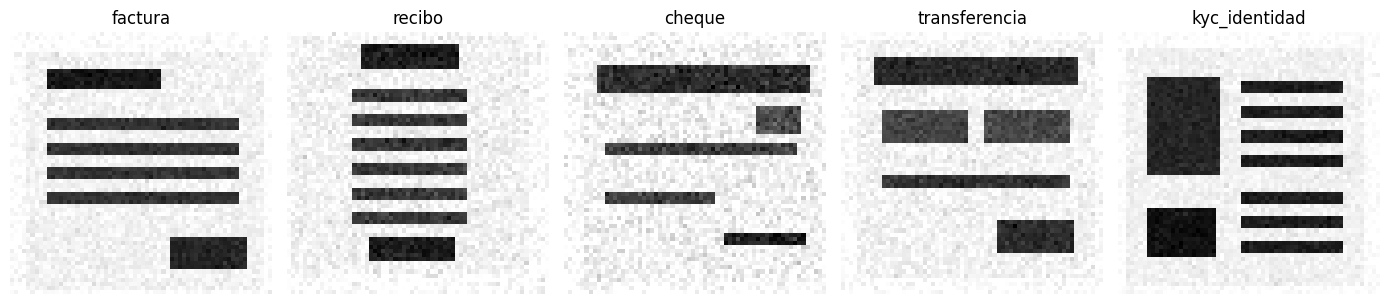

In [3]:
# Visualizamos ejemplos de cada clase
fig, axes = plt.subplots(1, N_CLASSES, figsize=(14, 3))
for label in range(N_CLASSES):
    idx = np.where(y == label)[0][0]
    axes[label].imshow(X[idx].squeeze(), cmap="gray")
    axes[label].set_title(CLASS_NAMES[label])
    axes[label].axis("off")
plt.tight_layout()
plt.show()

## 6. PARTICIÓN TRAIN / VALIDATION / TEST

In [4]:
# ============================================================
# 6. PARTICIÓN DE DATOS
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

y_train_cat = to_categorical(y_train, N_CLASSES)
y_val_cat = to_categorical(y_val, N_CLASSES)
y_test_cat = to_categorical(y_test, N_CLASSES)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (756, 64, 64, 1)
Validation: (162, 64, 64, 1)
Test: (162, 64, 64, 1)


## 7. MODELO CNN BASE

Empezamos con una CNN sencilla. En auditoría bancaria conviene comenzar con modelos simples antes de pasar a arquitecturas más grandes, porque:

- Son más fáciles de validar.
- Reducen el riesgo de sobreajuste.
- Son más rápidas de entrenar.
- Facilitan la explicación al comité de modelos o auditoría interna.

In [5]:
# ============================================================
# 7. DEFINICIÓN DEL MODELO CNN BASE
# ============================================================

cnn_model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation="relu", padding="same", name="last_conv"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.30),
    layers.Dense(N_CLASSES, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 285,829 (1.09 MB)

 Trainable params: 285,829 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

## 8. ENTRENAMIENTO DEL MODELO

In [6]:
# ============================================================
# 8. ENTRENAMIENTO
# ============================================================

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = cnn_model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5066 - loss: 1.2534 - val_accuracy: 1.0000 - val_loss: 0.3482
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9696 - loss: 0.1362 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9987 - loss: 0.0122 - val_accuracy: 1.0000 - val_loss: 1.0190e-04
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9987 - loss: 0.0054 - val_accuracy: 1.0000 - val_loss: 2.9269e-05
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 1.0000 - val_loss: 1.0494e-05
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9974 - loss: 0.0053 - val_accuracy: 1.0000 - val_loss: 5.1661e-05
Epoch 7/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 1.0000 - val_loss: 5.2805e-06
Epoch 8/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9987 - loss: 0.0059 - val_accurac

## 9. CURVAS DE APRENDIZAJE

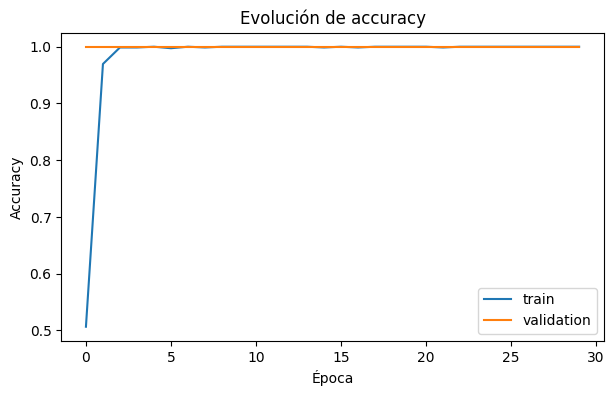

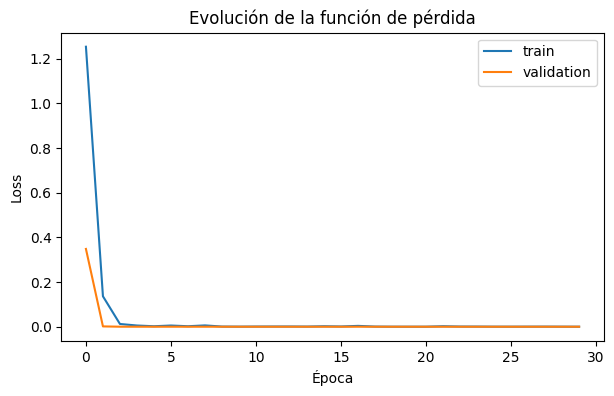

In [7]:
# Accuracy
plt.figure(figsize=(7,4))
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")
plt.title("Evolución de accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(7,4))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.title("Evolución de la función de pérdida")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 10. EVALUACIÓN EN TEST

In [8]:
# ============================================================
# 10. EVALUACIÓN
# ============================================================

test_loss, test_acc = cnn_model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Accuracy en test: {test_acc:.4f}")
print(f"Loss en test: {test_loss:.4f}")

y_prob = cnn_model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

Accuracy en test: 1.0000
Loss en test: 0.0000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
               precision    recall  f1-score   support

      factura       1.00      1.00      1.00        42
       recibo       1.00      1.00      1.00        33
       cheque       1.00      1.00      1.00        24
transferencia       1.00      1.00      1.00        36
kyc_identidad       1.00      1.00      1.00        27

     accuracy                           1.00       162
    macro avg       1.00      1.00      1.00       162
 weighted avg       1.00      1.00      1.00       162



## 11. MATRIZ DE CONFUSIÓN

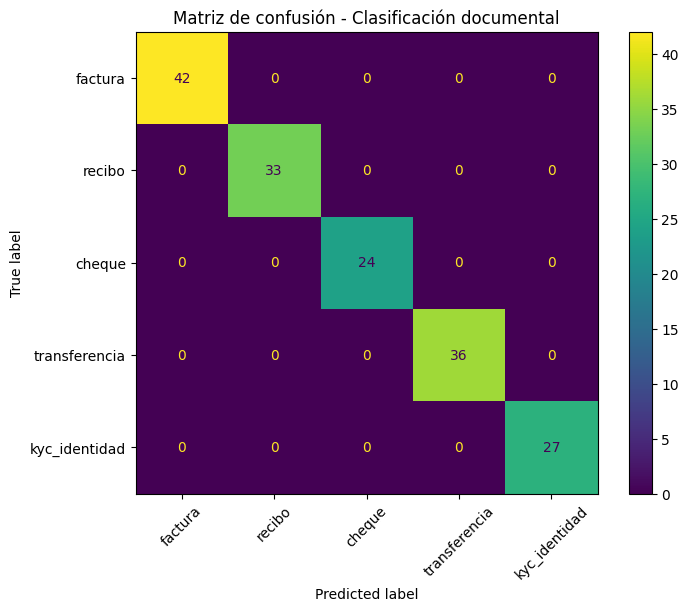

In [9]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Matriz de confusión - Clasificación documental")
plt.show()

## 12. INTERPRETACIÓN AUDITORA DE RESULTADOS

La matriz de confusión debe leerse desde una perspectiva de riesgo:

- Si una **factura** se clasifica como **recibo**, puede ser un error operativo moderado.
- Si un **cheque** se clasifica como otro documento, puede afectar controles específicos de firma y autorización.
- Si un documento **KYC** se clasifica mal, puede tener impacto regulatorio.
- Si el modelo confunde **transferencias** con otros documentos, puede afectar controles AML, conciliación o revisión de operaciones.

Preguntas auditoras recomendadas:

1. ¿Qué clases tienen más errores?
2. ¿Los errores se concentran en documentos de baja calidad?
3. ¿Hay una oficina, país, proveedor o canal que genere más errores?
4. ¿Las probabilidades del modelo son suficientemente altas?
5. ¿Qué documentos deben pasar siempre por revisión manual aunque el modelo acierte?

## 13. TOP-K ACCURACY

En auditoría puede ser útil que el modelo no dé una única respuesta, sino las 2 o 3 clases más probables. Si la clase correcta está entre las tres primeras, el sistema puede ayudar al auditor aunque no acierte la primera predicción.

In [10]:
# ============================================================
# 13. TOP-K ACCURACY
# ============================================================

def top_k_accuracy(y_true, y_prob, k=2):
    top_k = np.argsort(y_prob, axis=1)[:, -k:]
    return np.mean([y_true[i] in top_k[i] for i in range(len(y_true))])

for k in [1, 2, 3]:
    print(f"Top-{k} accuracy: {top_k_accuracy(y_test, y_prob, k):.4f}")

Top-1 accuracy: 1.0000
Top-2 accuracy: 1.0000
Top-3 accuracy: 1.0000


## 14. DETECCIÓN DE BAJA CONFIANZA

In [11]:
# ============================================================
# 14. CASOS DE BAJA CONFIANZA
# ============================================================

confidence = np.max(y_prob, axis=1)
results = pd.DataFrame({
    "y_real": [CLASS_NAMES[i] for i in y_test],
    "y_pred": [CLASS_NAMES[i] for i in y_pred],
    "confianza": confidence,
    "acierto": y_test == y_pred
})

results.sort_values("confianza").head(10)

,y_real,y_pred,confianza,acierto
0,transferencia,transferencia,1.0,True
1,factura,factura,1.0,True
2,transferencia,transferencia,1.0,True
3,kyc_identidad,kyc_identidad,1.0,True
4,recibo,recibo,1.0,True
5,recibo,recibo,1.0,True
6,factura,factura,1.0,True
7,cheque,cheque,1.0,True
8,factura,factura,1.0,True
9,kyc_identidad,kyc_identidad,1.0,True


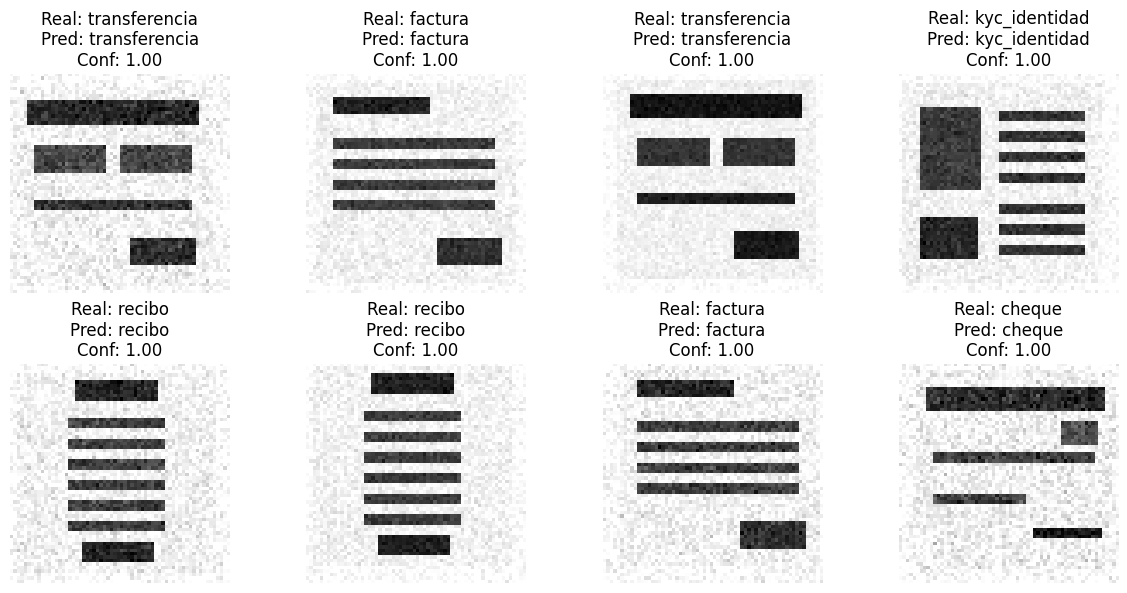

In [12]:
# Visualizar ejemplos de baja confianza
low_conf_idx = np.argsort(confidence)[:8]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.ravel()

for ax, idx in zip(axes, low_conf_idx):
    ax.imshow(X_test[idx].squeeze(), cmap="gray")
    ax.set_title(
        f"Real: {CLASS_NAMES[y_test[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]}\nConf: {confidence[idx]:.2f}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

## 15. DATA AUGMENTATION

El **data augmentation** permite simular variaciones habituales en documentos reales:

- Rotación leve.
- Desplazamiento.
- Zoom.
- Cambios de contraste.

En auditoría bancaria ayuda a que el modelo no dependa de documentos perfectamente escaneados.

In [13]:
# ============================================================
# 15. MODELO CON DATA AUGMENTATION
# ============================================================

augmentation = models.Sequential([
    layers.RandomRotation(0.03),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomZoom(0.05)
])

cnn_aug = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),
    augmentation,
    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same", name="last_conv_aug"),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.30),
    layers.Dense(N_CLASSES, activation="softmax")
])

cnn_aug.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
cnn_aug.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv_aug (Conv2D)          │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,781 (108.52 KB)

 Trainable params: 27,781 (108.52 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history_aug = cnn_aug.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

loss_aug, acc_aug = cnn_aug.evaluate(X_test, y_test_cat, verbose=0)
print(f"Accuracy CNN base: {test_acc:.4f}")
print(f"Accuracy CNN con augmentation: {acc_aug:.4f}")

Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.2500 - loss: 1.6045 - val_accuracy: 0.2593 - val_loss: 1.5898
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2593 - loss: 1.5918 - val_accuracy: 0.2593 - val_loss: 1.5848
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2593 - loss: 1.5886 - val_accuracy: 0.2593 - val_loss: 1.5772
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2738 - loss: 1.5795 - val_accuracy: 0.2593 - val_loss: 1.5616
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2791 - loss: 1.5670 - val_accuracy: 0.4815 - val_loss: 1.5187
Accuracy CNN base: 1.0000
Accuracy CNN con augmentation: 0.2593


## 16. GRAD-CAM PARA EXPLICABILIDAD VISUAL

Grad-CAM permite visualizar qué zonas de la imagen han tenido más peso en la predicción. En un uso auditor, estos mapas no son una prueba definitiva, pero ayudan a revisar si el modelo se fija en zonas razonables.

e:\TRABAJO\CURSOS\26WorkshopCaixabank\caixabank_formacion\.venv_tf\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 64, 64, 1))
  warnings.warn(msg)


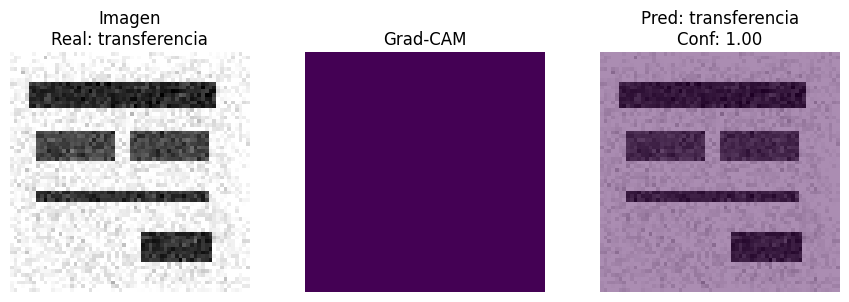

In [16]:
# ============================================================
# 16. FUNCIÓN GRAD-CAM
# ============================================================

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):

    # Forzar que el modelo esté construido/llamado
    _ = model(img_array)

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.outputs[0]
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

def show_gradcam(idx, model=cnn_model, last_conv_layer_name="last_conv"):
    img = X_test[idx]
    img_array = np.expand_dims(img, axis=0)
    probs = model.predict(img_array, verbose=0)[0]
    pred = np.argmax(probs)
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred)
    
    plt.figure(figsize=(9, 3))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(f"Imagen\nReal: {CLASS_NAMES[y_test[idx]]}")
    plt.axis("off")
    
    plt.subplot(1, 3, 2)
    plt.imshow(heatmap)
    plt.title("Grad-CAM")
    plt.axis("off")
    
    plt.subplot(1, 3, 3)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.imshow(tf.image.resize(heatmap[..., np.newaxis], (IMG_SIZE, IMG_SIZE)).numpy().squeeze(), alpha=0.45)
    plt.title(f"Pred: {CLASS_NAMES[pred]}\nConf: {probs[pred]:.2f}")
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()

# Ejemplo de explicación visual
show_gradcam(0)

## 17. CASUÍSTICA: CLASIFICACIÓN BINARIA DE DOCUMENTO SOSPECHOSO

Además de clasificar el tipo de documento, una entidad puede querer detectar si una imagen es **potencialmente sospechosa**.

Ejemplos de sospecha visual:

- Documento demasiado borroso.
- Recorte extraño.
- Zonas sobreescritas.
- Inconsistencia entre estructura visual y tipo declarado.
- Captura de pantalla en lugar de documento oficial.
- Documento duplicado con pequeñas alteraciones.

La variable objetivo pasaría a ser:

- `0 = normal`
- `1 = sospechoso`

El modelo cambiaría la última capa a una única neurona con `sigmoid` y la pérdida a `binary_crossentropy`.

In [17]:
# ============================================================
# 17. EJEMPLO DE ARQUITECTURA BINARIA
# ============================================================

binary_cnn_example = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.GlobalAveragePooling2D(),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

binary_cnn_example.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Recall(name="recall"), tf.keras.metrics.Precision(name="precision")]
)

binary_cnn_example.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,889 (23.00 KB)

 Trainable params: 5,889 (23.00 KB)

 Non-trainable params: 0 (0.00 B)

## 18. BUENAS PRÁCTICAS DE VALIDACIÓN EN BANCA

Checklist recomendada para auditores:

1. **Separación temporal**: entrenar con documentos antiguos y testar con documentos recientes.
2. **Separación por oficina/canal**: evitar que el modelo memorice formatos de una única fuente.
3. **Anonimización**: eliminar datos personales cuando sea posible.
4. **Control de versiones**: guardar datos, código, pesos del modelo y métricas.
5. **Revisión de errores**: analizar falsos positivos y falsos negativos.
6. **Explicabilidad visual**: revisar Grad-CAM en muestras críticas.
7. **Pruebas de robustez**: rotación, baja calidad, documentos incompletos.
8. **Monitorización**: drift en formatos documentales.
9. **Human-in-the-loop**: revisión humana para casos críticos o baja confianza.
10. **Gobernanza**: documentación para auditoría interna, riesgos y cumplimiento normativo.

## 19. LIMITACIONES DE LAS CNN EN AUDITORÍA

Las CNN presentan limitaciones importantes:

- No entienden el contenido semántico como lo haría un auditor.
- Pueden basarse en artefactos visuales irrelevantes.
- Requieren datos etiquetados y representativos.
- Son sensibles a cambios de formato.
- Su explicabilidad es parcial.
- Pueden fallar ante manipulaciones adversariales.
- No sustituyen controles de negocio, OCR, reglas ni revisión experta.

Por ello, su uso más razonable es como sistema de **apoyo, priorización y control documental**, no como mecanismo automático de decisión final.

## 20. EJEMPLO DE PIPELINE COMPLETO PARA AUDITORÍA DOCUMENTAL

In [18]:
# ============================================================
# 20. PIPELINE SIMPLIFICADO DE DECISIÓN AUDITORA
# ============================================================

def auditoria_documental_predictiva(imagen, modelo, umbral_confianza=0.70):
    """
    Pipeline simplificado:
    1. Predice tipo documental.
    2. Calcula confianza.
    3. Decide si requiere revisión manual.
    """
    probs = modelo.predict(np.expand_dims(imagen, axis=0), verbose=0)[0]
    pred = np.argmax(probs)
    conf = np.max(probs)
    
    decision = "aceptar_clasificacion_preliminar"
    if conf < umbral_confianza:
        decision = "revision_manual_por_baja_confianza"
    
    return {
        "tipo_predicho": CLASS_NAMES[pred],
        "confianza": float(conf),
        "decision": decision,
        "probabilidades": {CLASS_NAMES[i]: float(probs[i]) for i in range(N_CLASSES)}
    }

resultado = auditoria_documental_predictiva(X_test[0], cnn_model)
resultado

{'tipo_predicho': 'transferencia',
 'confianza': 1.0,
 'decision': 'aceptar_clasificacion_preliminar',
 'probabilidades': {'factura': 1.8054510794382472e-12,
  'recibo': 1.0713636094006763e-14,
  'cheque': 6.157271957921151e-13,
  'transferencia': 1.0,
  'kyc_identidad': 2.3557063689051e-14}}

## 21. 10 EJERCICIOS FINALES PARA RESOLVER CON NUEVOS DATOS

A continuación se proponen 10 ejercicios para que el alumnado trabaje con nuevos datos o con modificaciones del dataset sintético. La idea es simular casuísticas habituales en auditoría bancaria.

---

### Ejercicio 1: Nueva clase documental

Añade una sexta clase llamada `contrato_prestamo` con una estructura visual propia:

- Cabecera ancha.
- Varias líneas largas de texto.
- Una zona final de firma.

Entrena de nuevo la CNN y analiza la matriz de confusión.

---

### Ejercicio 2: Documentos de baja calidad

Genera una versión degradada del test aplicando:

- Más ruido.
- Desplazamientos.
- Menor contraste.

Compara el rendimiento del modelo base frente al modelo con data augmentation.

---

### Ejercicio 3: Desbalanceo extremo

Reduce la clase `cheque` a solo 30 imágenes de entrenamiento. Entrena el modelo y analiza:

- Recall de `cheque`.
- Confusiones principales.
- Impacto en accuracy global.

Después aplica `class_weight` y compara resultados.

---

### Ejercicio 4: Top-2 accuracy en revisión auditora

Calcula el Top-2 accuracy para cada clase documental. Interpreta si un sistema que propone dos clases posibles sería útil para reducir trabajo manual.

---

### Ejercicio 5: Umbral de confianza

Crea una tabla con diferentes umbrales de confianza:

- 0.50
- 0.60
- 0.70
- 0.80
- 0.90

Para cada umbral, calcula:

- Porcentaje de documentos enviados a revisión manual.
- Accuracy sobre los documentos aceptados automáticamente.

---

### Ejercicio 6: Grad-CAM en errores

Selecciona 5 documentos mal clasificados y genera sus mapas Grad-CAM. Responde:

- ¿El modelo se fija en zonas razonables?
- ¿Hay patrones visuales confusos?
- ¿Qué explicación darías a auditoría interna?

---

### Ejercicio 7: Clasificación binaria de sospecha visual

Crea una variable binaria `sospechoso` añadiendo alteraciones artificiales:

- Manchas negras.
- Recortes.
- Bloques superpuestos.
- Ruido elevado.

Entrena una CNN binaria para detectar documentos sospechosos.

---

### Ejercicio 8: Comparación CNN vs modelo tabular simple

Extrae características manuales de cada imagen:

- Media de intensidad.
- Desviación típica.
- Porcentaje de píxeles oscuros.
- Densidad por cuadrantes.

Entrena un Random Forest con esas variables y compara con la CNN.

---

### Ejercicio 9: Separación temporal simulada

Simula que los documentos nuevos tienen un formato ligeramente distinto:

- Mueve cabeceras.
- Cambia posiciones de totales.
- Añade nuevas líneas.

Evalúa si el modelo sufre drift visual.

---

### Ejercicio 10: Informe auditor final

Redacta un informe breve para un comité de auditoría bancaria incluyendo:

- Objetivo del modelo.
- Datos utilizados.
- Métricas principales.
- Clases con mayor riesgo.
- Limitaciones.
- Recomendaciones de uso.
- Necesidad de revisión humana.
- Evidencias XAI mediante Grad-CAM.

## 22. CONCLUSIONES

Las CNN son especialmente útiles en auditoría bancaria cuando se aplican a **documentos e imágenes financieras**, no solo a fotografías convencionales.

Aplicaciones razonables:

- Clasificación de tipología documental.
- Control de calidad de imágenes recibidas.
- Priorización de revisión manual.
- Detección preliminar de documentos visualmente sospechosos.
- Apoyo a pipelines con OCR, reglas de negocio y modelos tabulares.

Puntos críticos para auditores:

- No basta con entrenar y medir accuracy.
- Hay que analizar errores por clase.
- Hay que revisar baja confianza.
- Hay que validar robustez frente a cambios visuales.
- Hay que explicar predicciones con herramientas como Grad-CAM.
- Hay que mantener trazabilidad, gobernanza y revisión humana.

En un banco, el objetivo no es que la CNN decida sola, sino que ayude a mejorar la eficiencia y la cobertura del proceso auditor.